# Synthetic Control Method

# Data

In [1]:
import pandas as pd
from causalis.scenarios.synthetic_control.dgp import generate_scm_gamma_26

df = generate_scm_gamma_26(treatment_effect_rate=1.0, return_panel_data=False, include_oracles=True)

# Treated post-period rows are exactly treated_time == 1
post_treated = df[df["treated_time"] == 1].copy()
atte_true = post_treated["tau_realized_true"].mean()

print(f"Ground-truth ATTE is {atte_true:.6f}")

Ground-truth ATTE is 26.304803


In [2]:
df.head()

,unit_id,calendar_time,treated_time,observed,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true
0,donor_1,2000-01,0,1,20.991869,20.991869,0.0,16.323925,16.323925,0.0
1,donor_1,2000-02,0,1,12.909523,12.909523,0.0,21.129026,21.129026,0.0
2,donor_1,2000-03,0,1,12.206316,12.206316,0.0,23.366155,23.366155,0.0
3,donor_1,2000-04,0,1,48.256247,48.256247,0.0,29.439489,29.439489,0.0
4,donor_1,2000-05,0,1,22.137841,22.137841,0.0,16.254384,16.254384,0.0


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)
paneldata

PanelDataSCM(df=(1519, 5), y='y', unit_col='unit_id', time_col='calendar_time', treated_time='treated_time', time_freq='M', treated_unit='treated', treatment_start=Period('2003-02', 'M'), n_pre_periods=37, n_post_periods=12, donor_units=['donor_1', 'donor_10', 'donor_11', 'donor_12', 'donor_13', 'donor_14', 'donor_15', 'donor_16', 'donor_17', 'donor_18', 'donor_19', 'donor_2', 'donor_20', 'donor_21', 'donor_22', 'donor_23', 'donor_24', 'donor_25', 'donor_26', 'donor_27', 'donor_28', 'donor_29', 'donor_3', 'donor_30', 'donor_4', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [4]:
paneldata.df.head()

,unit_id,calendar_time,treated_time,observed,y
0,donor_1,2000-01,0,1,20.991869
1,donor_1,2000-02,0,1,12.909523
2,donor_1,2000-03,0,1,12.206316
3,donor_1,2000-04,0,1,48.256247
4,donor_1,2000-05,0,1,22.137841


# EDA

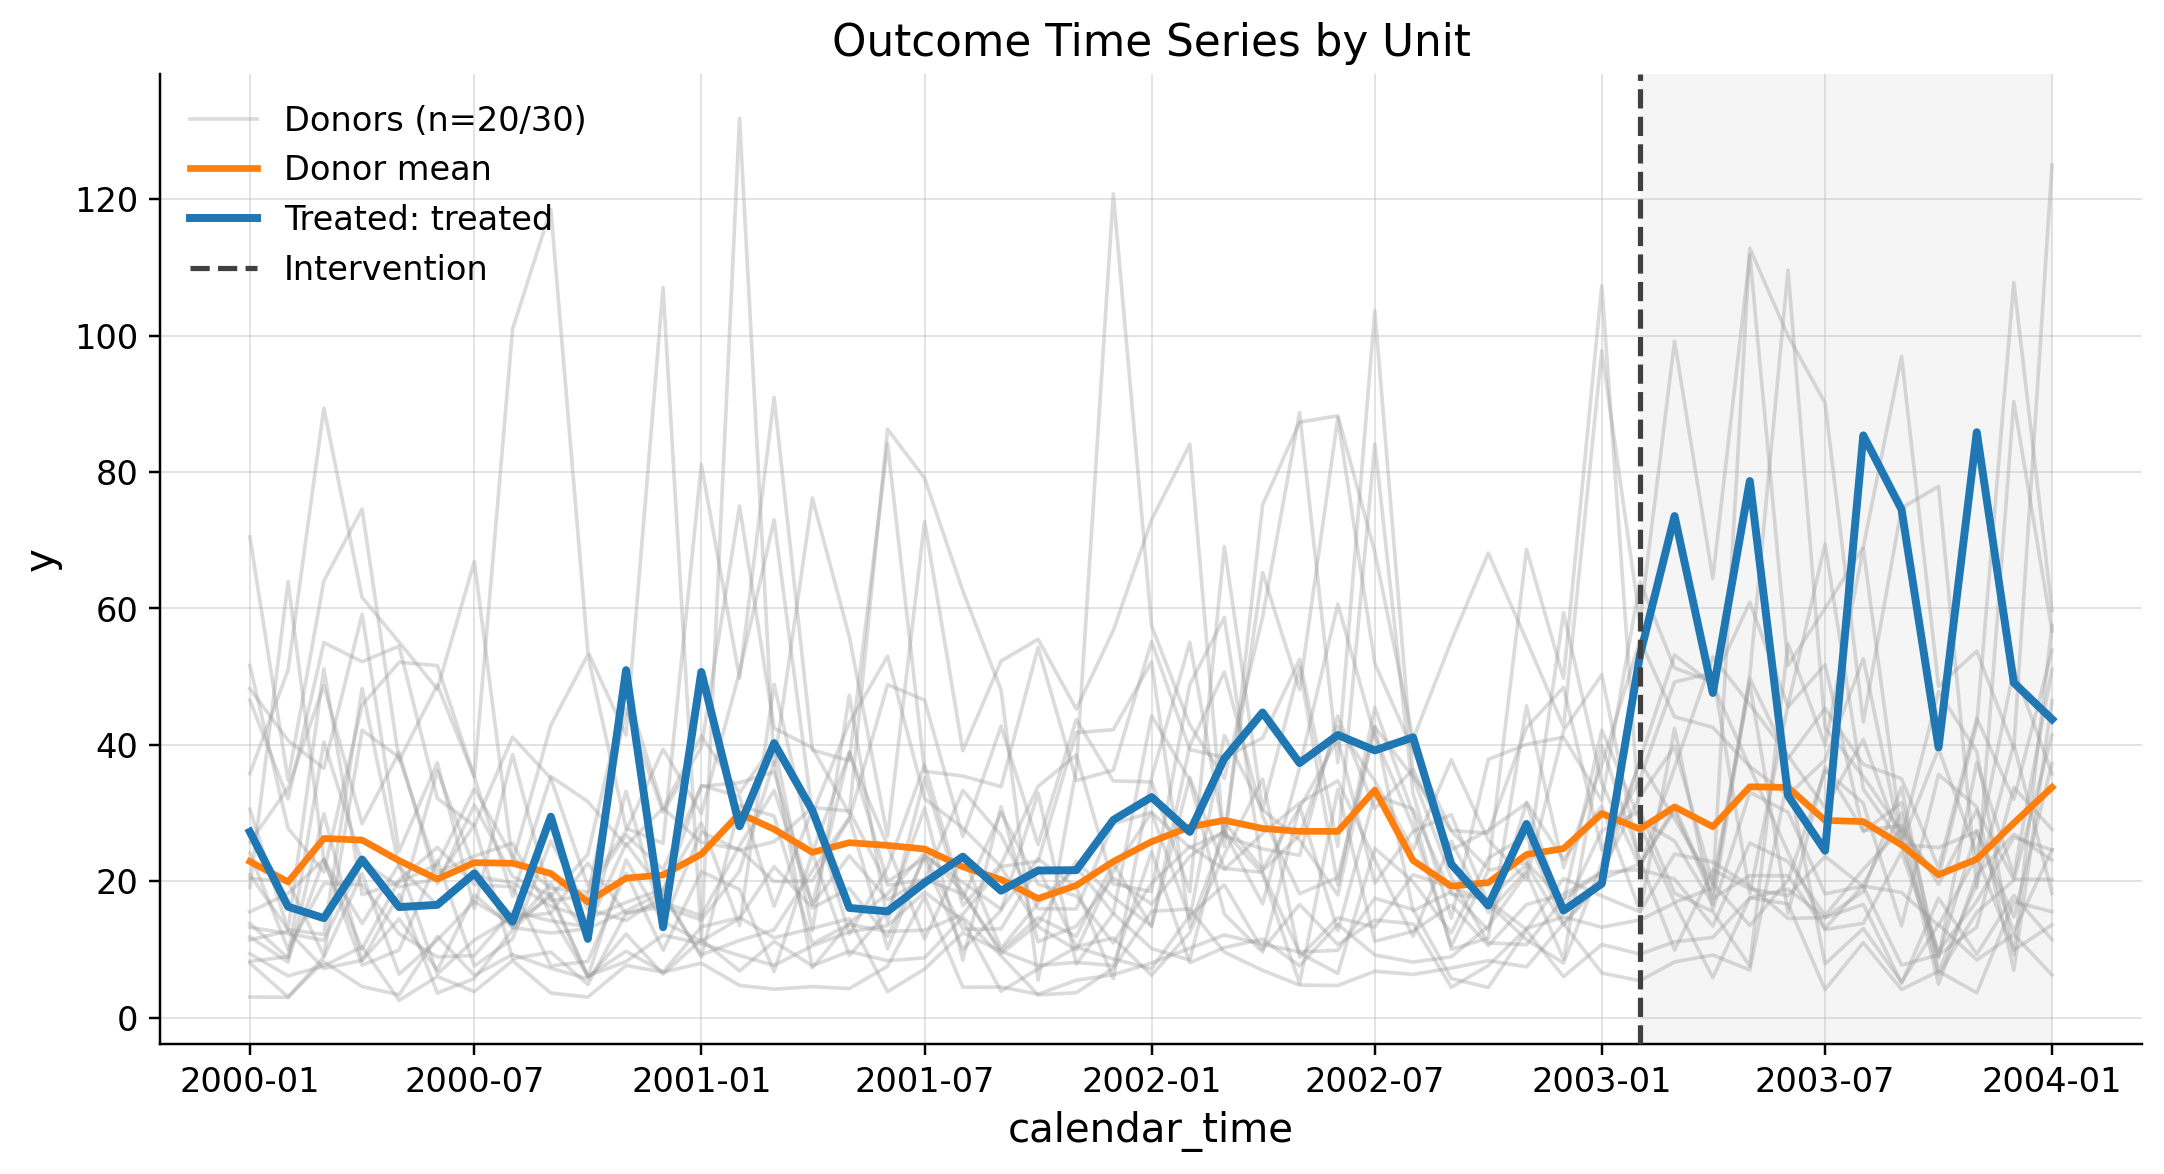

In [5]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot

outcome_panel_plot(paneldata)

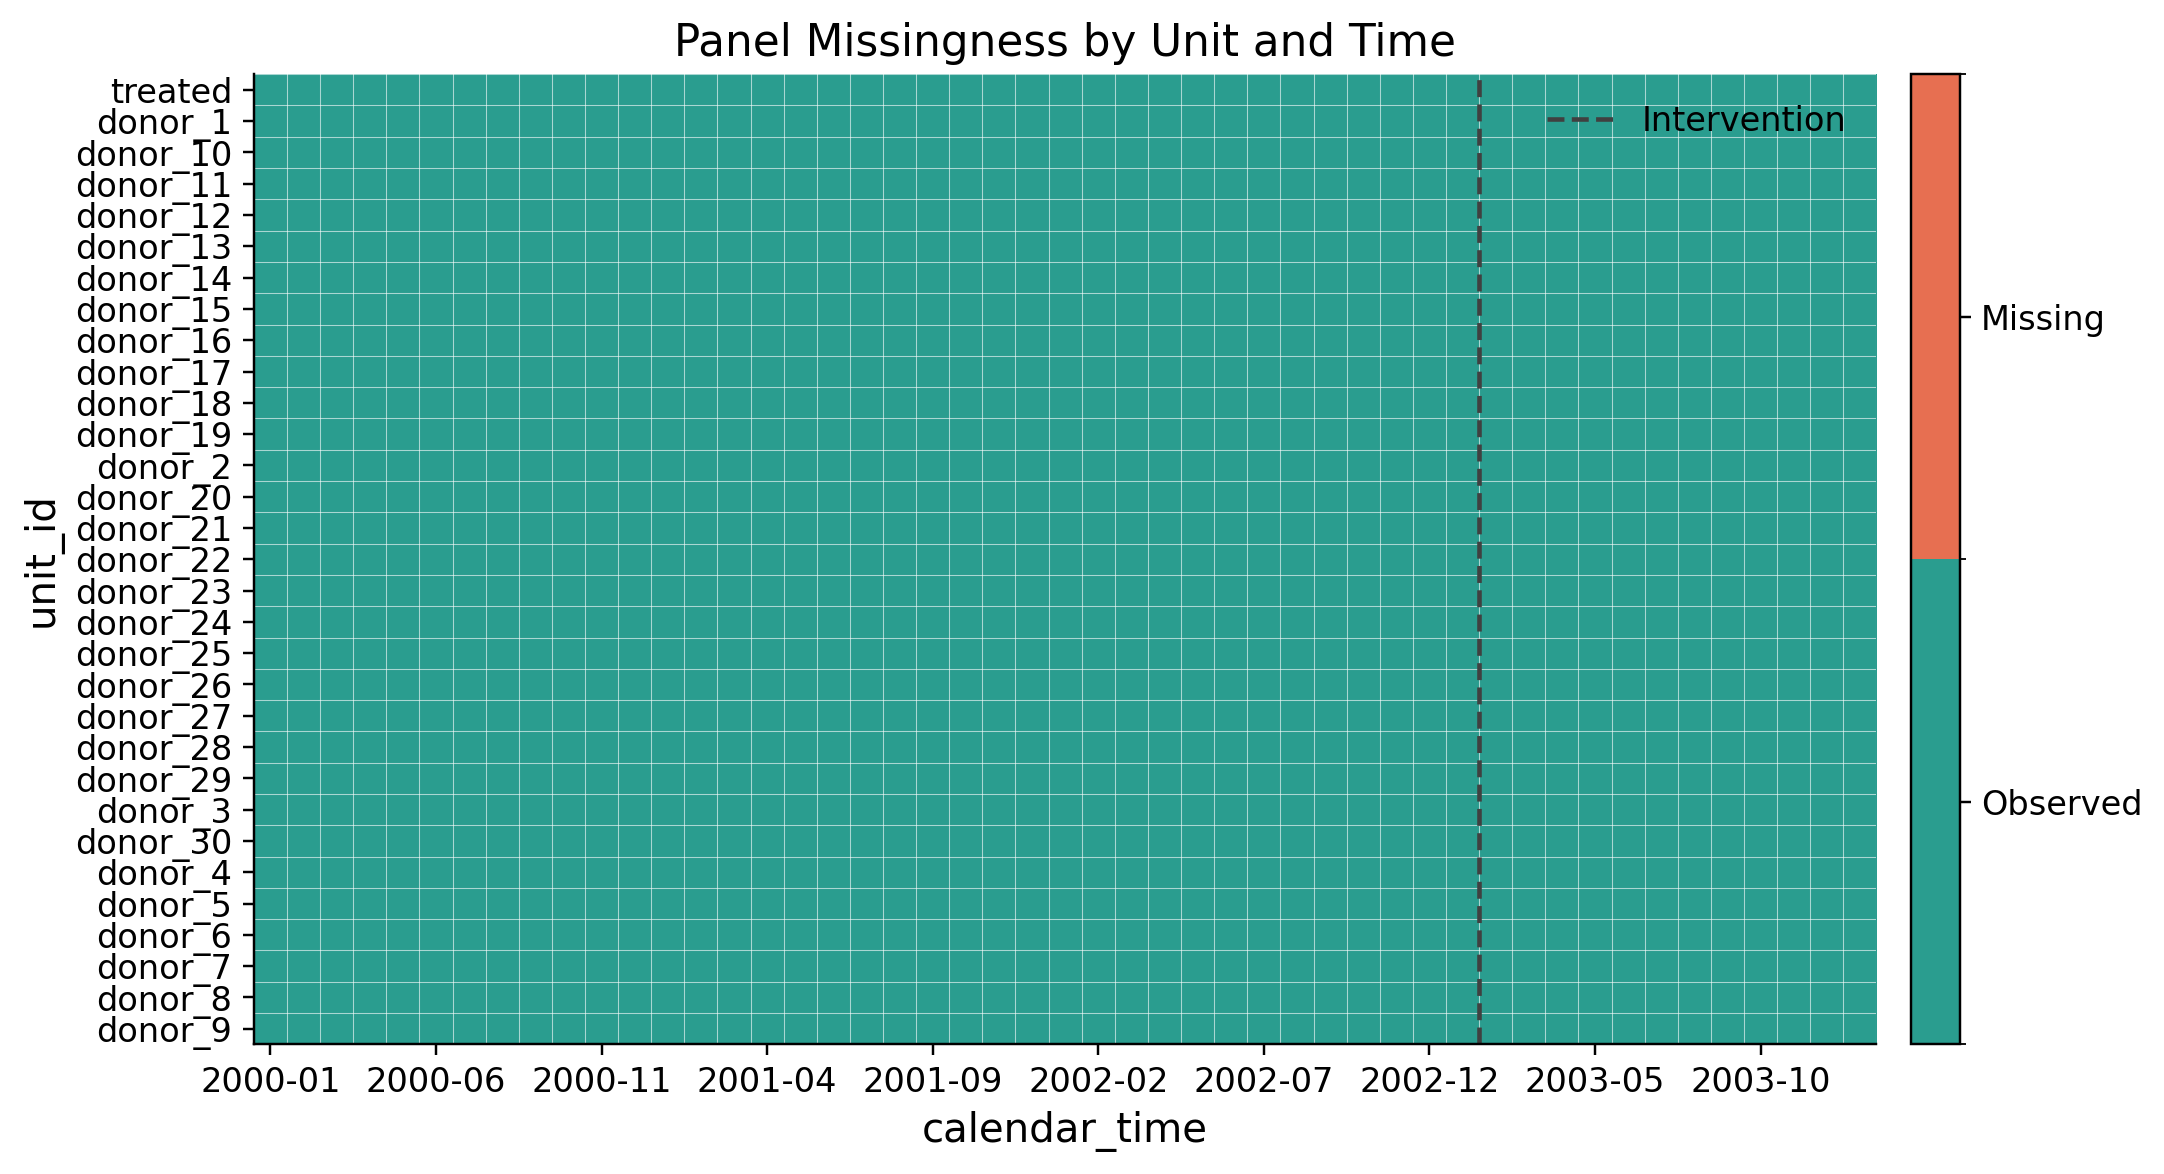

In [6]:
from causalis.scenarios.synthetic_control.refutation import missing_panel_plot

missing_panel_plot(paneldata)

# Inference

In [7]:
from causalis.scenarios.synthetic_control import AugmentedSyntheticControl
model = AugmentedSyntheticControl(
    lambda_aug=5,
    conformal_grid_scale_mult=12,
    conformal_grid_size=801
).fit(paneldata)
result = model.estimate()

/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:568: RuntimeWarning: Pointwise conformal confidence set touches the grid boundary; widen the grid.
  ) = self._invert_pointwise_ci_for_post_period(
/var/folders/m0/gys_jqqj44n801p04bgv_ct00000gn/T/ipykernel_91599/2284194181.py:6: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  ).fit(paneldata)


In [8]:
result.summary()

{'estimand': 'dynamic_effect_path',
 'model': 'AugmentedSyntheticControl',
 'inference': 'cwz_permutation_conformal_pointwise_moving_block_approximate',
 'alpha': 0.05,
 'n_post_periods': 12,
 'n_significant_periods': 0,
 'avg_point_estimate_across_post_periods': 26.907443780432658,
 'ci_type': 'pointwise',
 'multiple_testing_adjusted': False,
 'confidence_set_representation': 'grid_approximated_contiguous_segments',
 'period_results': [{'time': Period('2003-02', 'M'),
   'effect': -8.740808121192131,
   'ci_lower': -82.94229394975424,
   'ci_upper': 65.46067770736998,
   'p_value': 1.0,
   'is_significant': False,
   'confidence_set': [(-82.94229394975424, 65.46067770736998)]},
  {'time': Period('2003-03', 'M'),
   'effect': -18.692746991618407,
   'ci_lower': -92.89423282018052,
   'ci_upper': 55.50873883694371,
   'p_value': 0.9473684210526315,
   'is_significant': False,
   'confidence_set': [(-92.89423282018052, 55.50873883694371)]},
  {'time': Period('2003-04', 'M'),
   'effect':

In [9]:
result.p_value_by_time

2003-02    1.000000
2003-03    0.947368
2003-04    0.763158
2003-05    0.710526
2003-06    0.973684
2003-07    0.342105
2003-08    0.210526
2003-09    0.421053
2003-10    0.552632
2003-11    0.052632
2003-12    0.447368
2004-01    1.000000
Freq: M, Name: p_value_by_time, dtype: float64

# Refutation

In [10]:
from causalis.scenarios.synthetic_control.refutation import run_scm_diagnostics

run_scm_diagnostics(result, paneldata)

AttributeError: 'PanelEstimate' object has no attribute 'synthetic_outcome_sc'

In [ ]:
from causalis.scenarios.synthetic_control.refutation import observed_vs_synthetic_plot
observed_vs_synthetic_plot(result)

In [ ]:
from causalis.scenarios.synthetic_control.refutation import gap_over_time_plot
gap_over_time_plot(result)


In [ ]:
from causalis.scenarios.synthetic_control.refutation import placebo_att_histogram_plot
placebo_att_histogram_plot(result)